In [10]:
from langgraph.graph import StateGraph, START, END
from langchain_openai import ChatOpenAI
from typing import TypedDict
from dotenv import load_dotenv
import os

In [11]:
load_dotenv()

True

In [12]:
model = ChatOpenAI(
    model="llama-3.1-8b-instant",
    api_key=os.getenv("Grok_Api_key"),
    base_url="https://api.groq.com/openai/v1"
)

In [13]:
# Define State
class GenerateBlog(TypedDict):
    title:str
    outline:str
    blog:str
    evaluation:int

In [14]:
def create_outline(state: GenerateBlog) -> GenerateBlog:
    # fetch the title
    title = state['title']

    # call the llm
    prompt = f"Generate a detail outline for a blog on the topic {title}"
    outline = model.invoke(prompt).content
    
    # update the outline state
    state['outline'] = outline

    return state 

def create_blog(state: GenerateBlog) -> GenerateBlog:
    # fetch the title
    title = state['title']
    outline = state['outline']

    # call the llm
    prompt = f"Generate a detail blog on the title {title} using the following outline {outline}"
    blog = model.invoke(prompt).content
    
    # update the outline state
    state['blog'] = blog

    return state

def evaluation(state: GenerateBlog) -> GenerateBlog:
    # fetch the outlien or blog
    outline = state['outline']
    blog = state['blog']

    # call the llm
    prompt = f"Rate the following blog from 1-100 based on how well it follows the given outline and provide one-line feedback.\n\nOutline:\n{outline}\n\nBlog:\n{blog}"
    evaluation = model.invoke(prompt).content
    
    # update the outline state
    state['evaluation'] = evaluation

    return state 


In [15]:
# Define Graph
graph = StateGraph(GenerateBlog)

# add node from the graph
graph.add_node('create_outline', create_outline)
graph.add_node('create_blog', create_blog)
graph.add_node('evaluation_blog', evaluation)

# add edge from the graph
graph.add_edge(START, 'create_outline')
graph.add_edge('create_outline', 'create_blog')
graph.add_edge('create_blog', 'evaluation_blog')
graph.add_edge('evaluation_blog', END)

# Compile the graph
workflow = graph.compile()

In [16]:
initial_state = {'title': 'Rise of Ai in Pakistan'}

final_state = workflow.invoke(initial_state)

print(final_state)
print(final_state['outline'])
print(final_state['blog'])
print(final_state['evaluation'])

{'title': 'Rise of Ai in Pakistan', 'outline': "**Title:** The Rise of AI in Pakistan: Opportunities, Challenges, and Future Prospects\n\n**I. Introduction**\n\n- Brief overview of AI technology\n- Importance of AI in the global landscape\n- Introduction to Pakistan's context and its journey towards embracing AI\n- Thesis statement: Pakistan is rapidly embracing AI technology, driven by government initiatives, private sector investments, and talent pools, but it also faces challenges that need to be addressed.\n\n**II. Government Initiatives**\n\n- National AI Policy 2020: goals, objectives, and key initiatives\n- Role of the Ministry of IT and Telecom in promoting AI development\n- Public sector agencies' adoption of AI technologies\n- Collaborations between government and private sector organizations\n\n**III. Private Sector Investments**\n\n- Growth of AI startups in Pakistan, with notable examples\n- Investments by VCs, accelerators, and incubators in AI-focused startups\n- Large-s

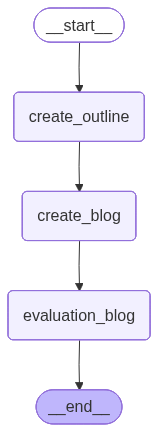

In [17]:
from IPython.display import Image

Image(workflow.get_graph().draw_mermaid_png())